For_figure4_analysis

for figure 4 (B)

In [2]:

"""Code for analyzing spreading area changes that used in Figure 4(B)
"""

import os
import numpy as np
import tifffile as tiff
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import linregress

# ================== USER SETTINGS ======================
# Mask files, and output directions
MASK_STACK_PATH = r"selected_masks_stack.tif"
OUT_DIR         = r"Reff_R0_transition_from_masks_jun10"

# Time iterations for CMOS dataset
DT_MIN    = 19.0   # 1 frame = 19 min

#  Unit for um/pixel
UM_PER_PX = 10.0   # 10 µm / pixel

# R0 deffinition
R0_TIME_MIN = 120

# local exponent window
WINDOW_POINTS = 15   
# settings for font and font size)
os.makedirs(OUT_DIR, exist_ok=True)
matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ==============================================================#
# Masks load                                     #
# ==============================================================#

def load_stack(path):
    arr = tiff.imread(path)
    if arr.ndim == 2:
        arr = arr[None, ...]
    else:
        H, W = arr.shape[-2], arr.shape[-1]
        T    = arr.size // (H * W)
        arr  = arr.reshape(T, H, W)
    return arr

labst = load_stack(MASK_STACK_PATH)   # [T,H,W]
T, H, W = labst.shape
print(f"[INFO] mask stack loaded: {labst.shape}")

labels = np.unique(labst)
labels = labels[labels > 0]  # 0=background 
print(f"[INFO] found {len(labels)} labels (cells)")

# ==============================================================#
# 2) Area calculations           #
# ==============================================================#

records = []

for t_idx in range(T):
    lab = labst[t_idx].astype(int)
    area_px_per_label = np.bincount(lab.ravel())
    for cid in labels:
        if cid >= len(area_px_per_label):
            continue
        area_px = int(area_px_per_label[cid])
        if area_px == 0:
            continue 

        area_um2 = area_px * (UM_PER_PX ** 2)
        Reff_um  = np.sqrt(area_um2 / np.pi)
        t_min    = t_idx * DT_MIN

        records.append({
            "t_frame": t_idx,
            "t_min": t_min,
            "cell_id": int(cid),
            "area_px": area_px,
            "area_um2": area_um2,
            "Reff_um": Reff_um
        })

df = pd.DataFrame(records)
print(f"[INFO] total valid (cell, t) records: {len(df)}")
print("[INFO] t_min range:", df["t_min"].min(), "→", df["t_min"].max())

# ==============================================================#
# 3) R0, Reff/Ro per samples                                #
# ==============================================================#

R0_list = []
for cid in sorted(df["cell_id"].unique()):
    d = df[df["cell_id"] == cid].sort_values("t_min")
    t_vals = d["t_min"].values
    R_vals = d["Reff_um"].values
    if len(t_vals) == 0:
        continue
    idx = np.argmin(np.abs(t_vals - R0_TIME_MIN))
    R0 = R_vals[idx]

    R0_list.append({"cell_id": cid,
                    "R0_um": R0,
                    "R0_t_min": t_vals[idx],
                    "R0_t_frame": int(d["t_frame"].iloc[idx])})

R0_df = pd.DataFrame(R0_list)
print("[INFO] R0 (first few rows):")
print(R0_df.head())

# merge
df = df.merge(R0_df[["cell_id", "R0_um"]], on="cell_id", how="left")
df["Reff_norm"] = df["Reff_um"] / df["R0_um"]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["Reff_norm"])

print("[INFO] after R0 merge / cleanup:", df.shape)

# ==============================================================#
# 4) Helper: sliding-window log–log exponent                    #
# ==============================================================#

def sliding_loglog_exponent(t, y, window=15):
    """
    t, y : 1D arrays (time, Reff_norm)
    window : number of points per window
    return:
       t_center (array), a_local (array)
    """
    t = np.asarray(t, float)
    y = np.asarray(y, float)

    mask = (t > 0) & (y > 0)
    t = t[mask]
    y = y[mask]
    if len(t) < window + 2:
        return np.array([]), np.array([])

    t_centers = []
    exponents = []

    for i in range(len(t) - window):
        t_win = t[i:i+window]
        y_win = y[i:i+window]
        if np.any(y_win <= 0) or np.any(t_win <= 0):
            continue

        log_t = np.log10(t_win)
        log_y = np.log10(y_win)

        slope, intercept, _, _, _ = linregress(log_t, log_y)
        t_centers.append(t_win.mean())
        exponents.append(slope)

    return np.asarray(t_centers), np.asarray(exponents)

# ==============================================================#
# 5) Helper: radial speed v_r(t)                                #
# ==============================================================#

def radial_speed(t, R):
    """
    simple finite difference speed (중간점 기준)
    t, R : 1D arrays (분, µm)
    return:
        t_mid (array), v (array)  [µm/min]
    """
    t = np.asarray(t, float)
    R = np.asarray(R, float)
    if len(t) < 2:
        return np.array([]), np.array([])
    dt = np.diff(t)
    dR = np.diff(R)
    mask = dt > 0
    t_mid = 0.5 * (t[:-1] + t[1:])
    v = dR / dt
    return t_mid[mask], v[mask]

# ==============================================================#
# 6) Exponent, Speeds                     #
# ==============================================================#

rows_exponent = []
rows_speed    = []

for cid in sorted(df["cell_id"].unique()):
    d = df[df["cell_id"] == cid].sort_values("t_min")
    t = d["t_min"].values
    Rn = d["Reff_norm"].values
    R  = d["Reff_um"].values

    # local exponent
    t_c, a_loc = sliding_loglog_exponent(t, Rn, window=WINDOW_POINTS)
    for tc, aa in zip(t_c, a_loc):
        rows_exponent.append({
            "cell_id": cid,
            "t_min": tc,
            "a_local": aa
        })

    # radial speed
    t_mid, v = radial_speed(t, R)
    for tm, vv in zip(t_mid, v):
        rows_speed.append({
            "cell_id": cid,
            "t_min": tm,
            "v_um_per_min": vv
        })

exp_df   = pd.DataFrame(rows_exponent)
speed_df = pd.DataFrame(rows_speed)

print("[INFO] exponent points:", exp_df.shape)
print("[INFO] speed points:", speed_df.shape)

# ==============================================================#
# 7) Helper: binning → mean ± std                               #
# ==============================================================#

def bin_and_mean(df_in, t_col, y_col, nbins=40):
    if df_in.empty:
        return np.array([]), np.array([]), np.array([])

    t_vals = df_in[t_col].values
    y_vals = df_in[y_col].values

    t_min = t_vals.min()
    t_max = t_vals.max()
    edges = np.linspace(t_min, t_max, nbins+1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    means = []
    stds  = []
    for i in range(nbins):
        mask = (t_vals >= edges[i]) & (t_vals < edges[i+1])
        y_bin = y_vals[mask]
        if np.any(np.isfinite(y_bin)):
            means.append(np.nanmean(y_bin))
            stds.append(np.nanstd(y_bin))
        else:
            means.append(np.nan)
            stds.append(np.nan)

    return centers, np.asarray(means), np.asarray(stds)

t_exp, a_mean, a_std = bin_and_mean(exp_df,   "t_min", "a_local",      nbins=40)
t_v,   v_mean, v_std = bin_and_mean(speed_df, "t_min", "v_um_per_min", nbins=40)

marker_list = ["o", "s", "^", "D", "v", "P", "X", "*"]
color_list  = ["tab:blue", "tab:orange", "tab:green", "tab:red",
               "tab:purple", "tab:brown", "tab:pink", "tab:gray"]

figA, axA = plt.subplots(figsize=(3.5, 2.8), dpi=300)

for i, cid in enumerate(sorted(df["cell_id"].unique())):
    d = df[df["cell_id"] == cid].sort_values("t_min")
    m = marker_list[i % len(marker_list)]
    c = color_list[i % len(color_list)]
    axA.scatter(d["t_min"], d["Reff_norm"],
                s=9, marker=m, edgecolors="none", alpha=0.5,
                label=f"cell {cid}")

axA.set_xlabel("t (min)")
axA.set_ylabel(r"$R_{\mathrm{eff}}/R_0$")
axA.set_xlim(left=0)
axA.spines["top"].set_visible(False)
axA.spines["right"].set_visible(False)
axA.tick_params(direction="out", length=3)

handles, labels_ = axA.get_legend_handles_labels()
if len(handles) <= 4:
    axA.legend(frameon=False)
else:
    axA.legend(handles[:4], labels_[:4], frameon=False, title="examples")

figA.tight_layout()
figA_path = os.path.join(OUT_DIR, "FigA_Reff_over_R0_vs_time.png")
figA.savefig(figA_path, bbox_inches="tight")
plt.close(figA)
print("[SAVE] FigA →", figA_path)

figB, axB = plt.subplots(figsize=(3.5, 2.8), dpi=300)

for cid in sorted(exp_df["cell_id"].unique()):
    d = exp_df[exp_df["cell_id"] == cid].sort_values("t_min")
    axB.plot(d["t_min"], d["a_local"], lw=0.4, alpha=0.3)

axB.plot(t_exp, a_mean, "k-", lw=1.2, label="mean a(t)")
axB.fill_between(t_exp, a_mean - a_std, a_mean + a_std,
                 color="k", alpha=0.15, linewidth=0, label="±1 s.d.")

axB.axhline(1/3, color="tab:blue", ls="--", lw=0.8, label=r"$a=1/3$")
axB.axhline(1.0, color="tab:red",  ls="--", lw=0.8, label=r"$a=1$")

axB.set_xlabel("t (min)")
axB.set_ylabel(r"local exponent $a(t)$")
axB.set_xlim(left=0)
axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)
axB.tick_params(direction="out", length=3)
axB.legend(frameon=False, fontsize=7)

figB.tight_layout()
figB_path = os.path.join(OUT_DIR, "FigB_local_exponent_vs_time.png")
figB.savefig(figB_path, bbox_inches="tight")
plt.close(figB)
print("[SAVE] FigB →", figB_path)

# ==============================================================#
# 10) Fig C: radial speed v_r(t)                                #
# ==============================================================#

figC, axC = plt.subplots(figsize=(3.5, 2.8), dpi=300)

for cid in sorted(speed_df["cell_id"].unique()):
    d = speed_df[speed_df["cell_id"] == cid].sort_values("t_min")
    axC.plot(d["t_min"], d["v_um_per_min"], lw=0.4, alpha=0.3)

axC.plot(t_v, v_mean, "k-", lw=1.2, label="mean speed")
axC.fill_between(t_v, v_mean - v_std, v_mean + v_std,
                 color="k", alpha=0.15, linewidth=0, label="±1 s.d.")

axC.set_xlabel("t (min)")
axC.set_ylabel(r"$v_r(t)$ (µm/min)")
axC.set_xlim(left=0)
axC.spines["top"].set_visible(False)
axC.spines["right"].set_visible(False)
axC.tick_params(direction="out", length=3)
axC.legend(frameon=False, fontsize=7)

figC.tight_layout()
figC_path = os.path.join(OUT_DIR, "FigC_radial_speed_vs_time.png")
figC.savefig(figC_path, bbox_inches="tight")
plt.close(figC)
print("[SAVE] FigC →", figC_path)

print("[DONE] All figures saved in:", OUT_DIR)



[INFO] mask stack loaded: (155, 1024, 1024)
[INFO] found 4 labels (cells)
[INFO] total valid (cell, t) records: 620
[INFO] t_min range: 0.0 → 2926.0
[INFO] R0 (first few rows):
   cell_id       R0_um  R0_t_min  R0_t_frame
0        1  146.689292     114.0           6
1        2  164.294487     114.0           6
2        3  248.563772     114.0           6
3        4  184.637452     114.0           6
[INFO] after R0 merge / cleanup: (620, 8)
[INFO] exponent points: (556, 3)
[INFO] speed points: (616, 3)
[SAVE] FigA → C:\Users\oxfil\Reff_R0_transition_from_masks_jun10\FigA_Reff_over_R0_vs_time.png
[SAVE] FigB → C:\Users\oxfil\Reff_R0_transition_from_masks_jun10\FigB_local_exponent_vs_time.png
[SAVE] FigC → C:\Users\oxfil\Reff_R0_transition_from_masks_jun10\FigC_radial_speed_vs_time.png
[DONE] All figures saved in: C:\Users\oxfil\Reff_R0_transition_from_masks_jun10


===== Mean curve endpoint-based rates =====
0-10 hr rate  = 20.602 µm/hr
30-40 hr rate = 7.172 µm/hr


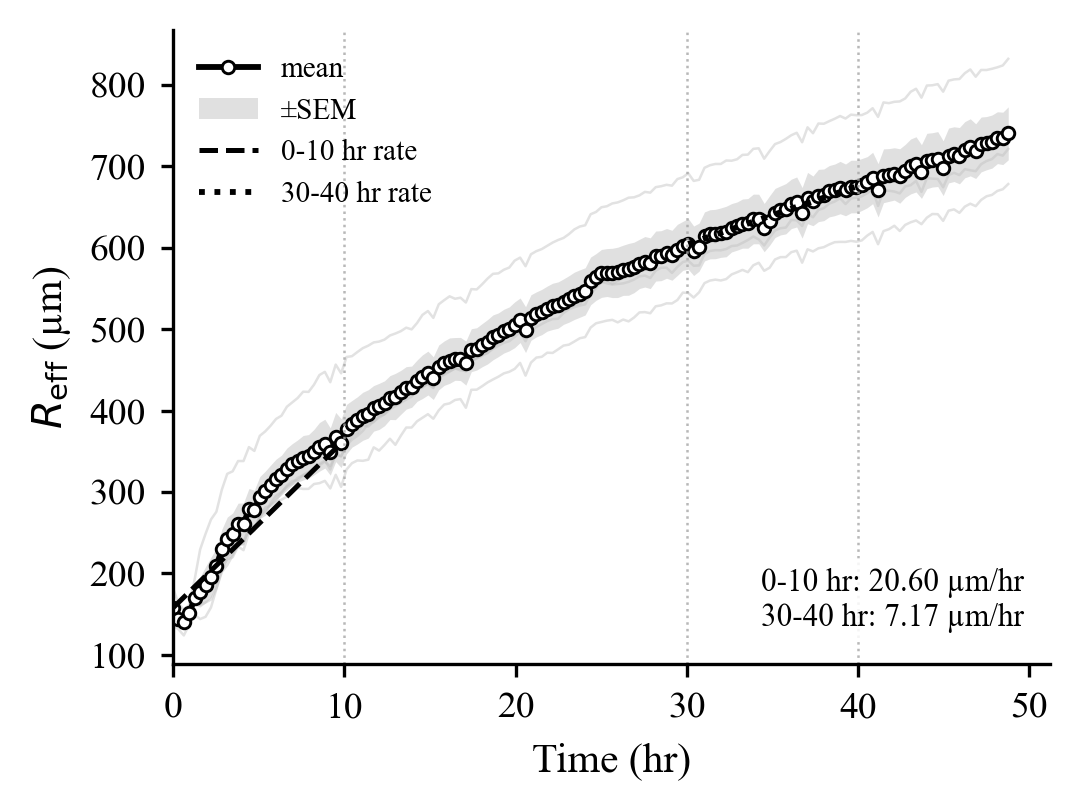

[SAVE] PDF: C:\Users\oxfil\Reff_R0_transition_from_masks_apr428\FigD_mean_radius_rate_windows.pdf
[SAVE] PNG: C:\Users\oxfil\Reff_R0_transition_from_masks_apr428\FigD_mean_radius_rate_windows.png
[SAVE] CSV: C:\Users\oxfil\Reff_R0_transition_from_masks_apr428\FigD_mean_radius_by_time.csv


In [10]:
TIME_COL = "t_min"
ID_COL   = "cell_id"
R_COL    = "Reff_um"

EARLY_WIN = (0, 10)     # hours
LATE_WIN  = (30, 40)    # hours

OUT_PDF = os.path.join(OUT_DIR, "FigD_mean_radius_rate_windows.pdf")
OUT_PNG = os.path.join(OUT_DIR, "FigD_mean_radius_rate_windows.png")
OUT_CSV = os.path.join(OUT_DIR, "FigD_mean_radius_by_time.csv")

df_plot = df.copy()
df_plot["t_hr"] = df_plot[TIME_COL] / 60.0

mean_df = (
    df_plot
    .groupby("t_hr")[R_COL]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={
        "mean": "R_mean",
        "std": "R_std",
        "count": "n"
    })
)

mean_df["R_sem"] = mean_df["R_std"] / np.sqrt(mean_df["n"])

mean_df.to_csv(OUT_CSV, index=False)


def compute_mean_endpoint_rate(mean_df, t_start, t_end):
    d = mean_df[
        (mean_df["t_hr"] >= t_start) &
        (mean_df["t_hr"] <= t_end)
    ].sort_values("t_hr")

    if len(d) < 2:
        return {
            "rate": np.nan,
            "t0": np.nan,
            "t1": np.nan,
            "r0": np.nan,
            "r1": np.nan,
            "n_points": len(d)
        }

    t0 = d["t_hr"].iloc[0]
    t1 = d["t_hr"].iloc[-1]
    r0 = d["R_mean"].iloc[0]
    r1 = d["R_mean"].iloc[-1]

    rate = (r1 - r0) / (t1 - t0)

    return {
        "rate": rate,
        "t0": t0,
        "t1": t1,
        "r0": r0,
        "r1": r1,
        "n_points": len(d)
    }


early_rate = compute_mean_endpoint_rate(mean_df, EARLY_WIN[0], EARLY_WIN[1])
late_rate  = compute_mean_endpoint_rate(mean_df, LATE_WIN[0], LATE_WIN[1])

print("===== Mean curve endpoint-based rates =====")
print(f"0-10 hr rate  = {early_rate['rate']:.3f} µm/hr")
print(f"30-40 hr rate = {late_rate['rate']:.3f} µm/hr")


#Plot

fig, ax = plt.subplots(figsize=(3.7, 2.8), dpi=300)


for cid in sorted(df_plot[ID_COL].unique()):
    sub = df_plot[df_plot[ID_COL] == cid].sort_values("t_hr")

    ax.plot(
        sub["t_hr"],
        sub[R_COL],
        color="0.75",
        lw=0.6,
        alpha=0.45
    )

# Mean ± SEM
ax.plot(
    mean_df["t_hr"],
    mean_df["R_mean"],
    color="black",
    lw=1.4,
    marker="o",
    markersize=3.0,
    markerfacecolor="white",
    markeredgecolor="black",
    markeredgewidth=0.7,
    label="mean"
)

ax.fill_between(
    mean_df["t_hr"],
    mean_df["R_mean"] - mean_df["R_sem"],
    mean_df["R_mean"] + mean_df["R_sem"],
    color="0.4",
    alpha=0.20,
    linewidth=0,
    label="±SEM"
)

#  endpoint-rate guide line
if np.isfinite(early_rate["rate"]):
    ax.plot(
        [early_rate["t0"], early_rate["t1"]],
        [early_rate["r0"], early_rate["r1"]],
        color="black",
        linestyle="--",
        lw=1.2,
        label="0-10 hr rate"
    )

if np.isfinite(late_rate["rate"]):
    ax.plot(
        [late_rate["t0"], late_rate["t1"]],
        [late_rate["r0"], late_rate["r1"]],
        color="black",
        linestyle=":",
        lw=1.4,
        label="30-40 hr rate"
    )

# window boundaries
for xx in [EARLY_WIN[0], EARLY_WIN[1], LATE_WIN[0], LATE_WIN[1]]:
    ax.axvline(
        xx,
        color="0.65",
        linestyle=":",
        linewidth=0.6,
        alpha=0.8
    )

# ------------------------------------------------------------
# Rate text
# ------------------------------------------------------------
textstr = (
    f"0-10 hr: {early_rate['rate']:.2f} µm/hr\n"
    f"30-40 hr: {late_rate['rate']:.2f} µm/hr"
)

ax.text(
    0.97, 0.05,
    textstr,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=7.5,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85,
        edgecolor="none"
    )
)

ax.set_xlabel("Time (hr)")
ax.set_ylabel(r"$R_{\mathrm{eff}}$ (µm)")
ax.set_xlim(left=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out", length=3)

ax.legend(frameon=False, fontsize=7)

fig.tight_layout()
fig.savefig(OUT_PDF, bbox_inches="tight")
fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("[SAVE] PDF:", OUT_PDF)
print("[SAVE] PNG:", OUT_PNG)
print("[SAVE] CSV:", OUT_CSV)

For Figure 4(C)

In [111]:
import os
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
import matplotlib
from skimage import measure

# ================= PATH SETTINGS ======================
RGB_IMG_PATH   = r"CMOS_0728_BlueRscale.tif"   # RGB images for CMOS_capacitance
MASK_STACK_PATH = r"selected_masks_stack.tif"
OUT_DIR         = r"overlay_RGB_masks"

os.makedirs(OUT_DIR, exist_ok=True)

# Font setting
matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

# ================= LOAD FUNCTIONS =======================

def load_stack(path):
    arr = tiff.imread(path)

    # Case 1: single RGB image (H,W,3)
    if arr.ndim == 3 and arr.shape[-1] == 3:
        arr = arr[None, ...]   # [1, H, W, 3]

    # Case 2: multi-page RGB TIFF (T,H,W,3)
    elif arr.ndim == 4 and arr.shape[-1] == 3:
        pass

    # Case 3: grayscale TIFF
    elif arr.ndim == 2:
        arr = arr[None, ..., None]  # convert to (T,H,W,1)
    elif arr.ndim == 3 and arr.shape[-1] != 3:
        arr = arr[..., None]

    return arr

# Load RGB stack
imgs = load_stack(RGB_IMG_PATH)   # shape: [T,H,W,3]
masks = load_stack(MASK_STACK_PATH)  # shape: [T,H,W] or [T,H,W,1]

# If mask has extra channel, squeeze
if masks.ndim == 4:
    masks = masks[..., 0]

T_img, H_img, W_img, C_img = imgs.shape
T_mask, H_mask, W_mask = masks.shape

print(f"[INFO] RGB images: {imgs.shape}")
print(f"[INFO] masks     : {masks.shape}")

if (H_img != H_mask) or (W_img != W_mask):
    raise ValueError("No matching between RGB and Mask")

T_common = min(T_img, T_mask)
print(f"[INFO] Using {T_common} frames for overlay.")

# ================= PROCESS ALL FRAMES =================

for t in range(T_common):
    rgb = imgs[t].astype(float)
    lab = masks[t].astype(int)

    # normalize RGB for visualization
    if rgb.max() > 0:
        rgb_vis = rgb / rgb.max()
    else:
        rgb_vis = rgb

    fig, ax = plt.subplots(figsize=(4, 4), dpi=300)
    ax.imshow(rgb_vis)

    # unique labels to draw
    unique_ids = np.unique(lab)
    unique_ids = unique_ids[unique_ids > 0]

    # assign colors for each label
    colors = plt.cm.tab20(np.linspace(0, 1, max(1, len(unique_ids))))

    for idx, cid in enumerate(unique_ids):
        binary = (lab == cid).astype(np.uint8)
        contours = measure.find_contours(binary, 0.5)

        for c in contours:
            ax.plot(c[:, 1], c[:, 0], lw=0.5, color='red')

    ax.set_title(f"Frame {t}")
    ax.set_axis_off()

    save_path = os.path.join(OUT_DIR, f"overlay_RGB_{t:04d}.png")
    fig.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

    print(f"[SAVED] {save_path}")

print(f"[DONE] All overlays saved in: {OUT_DIR}")


[INFO] RGB images: (155, 1024, 1024, 3)
[INFO] masks     : (155, 1024, 1024)
[INFO] Using 155 frames for overlay.
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0000.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0001.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0002.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0003.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0004.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0005.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0006.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0007.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0008.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0009.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0010.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0011.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0012.png
[SAVED] C:\Users\oxfil\overlay_RGB_masks\overlay_RGB_0013.png
[SAVED] C:\Users\o

For Figure(D)

In [12]:
"""
Time–Radius map of radial velocity for ONE representative spheroid.
"""

import os
import numpy as np
import cv2
import tifffile as tiff
from skimage.measure import regionprops
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import LinearSegmentedColormap

# ===================== USER SETTINGS =====================
cmap_custom = LinearSegmentedColormap.from_list(
    "white_orange_red",
    [
        (0.0, "white"),
        (0.25, "yellow"),
        (0.5, "orange"),    
        (1.0, "#ff0000"),
    ]
)
IMG_STACK_PATH  = r"CMOS_images_0728_spheroid.tif"
MASK_STACK_PATH = r"selected_masks_stack.tif"

OUT_DIR         = r"mask_flow_radius_map_rep_0616"
os.makedirs(OUT_DIR, exist_ok=True)

MASK_T_OFFSET   = 2     # image t = MASK_T_OFFSET corresponds to mask t = 0 due to the initial unattachment

# Label for representative spheroid
REP_LABEL       = 4     

UM_PER_PX       = 10.0  # µm/px
DT_MIN          = 19.0  # min/frame

# r-bin length
DR_UM               = 10.0
MIN_PIXELS_PER_BIN  = 20  

# Usage of velocity magnitude 
USE_ABS_VELOCITY = True

# Representative velocity color for slow (µm/h)
V_REF      = 4.0      # slow velocity
V_REF_TOL  = 1.5      

MID_FRAC_MIN = 0.2  
MID_FRAC_MAX = 0.9 

# Smooting coefficient for time
SMOOTH_SIGMA_T = 1.5

# Optical flow params (Farneback)
FB_PARAMS = dict(
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)

# ===================== HELPER FUNCTIONS =====================

def _to_gray_float(img):
    if img.ndim == 3 and img.shape[2] in (3, 4):
        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY if img.shape[2] == 3 else cv2.COLOR_BGRA2GRAY
        )
    return img.astype(np.float32, copy=False)

def _load_stack(path):
    arr = tiff.imread(path)
    if arr.ndim == 2:
        arr = arr[None, ...]
    else:
        H, W = arr.shape[-2], arr.shape[-1]
        T   = arr.size // (H * W)
        arr = arr.reshape(T, H, W)
    return arr

def _flow(prev, nxt):
    return cv2.calcOpticalFlowFarneback(prev, nxt, None, **FB_PARAMS)

def _to_units(a):
    # px/frame -> µm/h
    if UM_PER_PX and DT_MIN:
        return a * UM_PER_PX * (60.0 / DT_MIN)
    return a

# ===================== MAIN FUNCTION =====================

def build_time_radius_map_rep_spheroid():
    imgs_full  = _load_stack(IMG_STACK_PATH)   # (T_img, H, W)
    masks_full = _load_stack(MASK_STACK_PATH)  # (T_mask, H, W)

    if imgs_full.shape[-2:] != masks_full.shape[-2:]:
        raise ValueError("Image and mask shapes differ.")

    T_img, H, W = imgs_full.shape
    T_mask      = masks_full.shape[0]

    max_len_from_images = T_img - MASK_T_OFFSET
    T_aligned = min(T_mask, max_len_from_images)

    imgs  = imgs_full[MASK_T_OFFSET : MASK_T_OFFSET + T_aligned]
    masks = masks_full[:T_aligned]
    T     = T_aligned

    print(f"[ALIGN] Using {T} frames (flow count = {T-1})")
    
    mask0 = masks[0].astype(np.int32)
    labels = np.unique(mask0)
    labels = labels[labels > 0]

    print(f"[INFO] Labels at t=0: {labels}")

    if REP_LABEL not in labels:
        raise RuntimeError(f"REP_LABEL={REP_LABEL} not found in t=0 mask.")

    m0 = (mask0 == REP_LABEL)
    props = regionprops(m0.astype(np.uint8))
    cy0, cx0 = props[0].centroid   # (row, col)
    print(f"[CENTER] label {REP_LABEL} center (cx0, cy0) = ({cx0:.2f}, {cy0:.2f})")

    flows = []
    for t in range(T - 1):
        f = _flow(_to_gray_float(imgs[t]), _to_gray_float(imgs[t+1]))
        flows.append(f)
    flows = np.asarray(flows)  # (T-1, H, W, 2)
    T_flow = T - 1

    time_r_um_list = []
    time_vr_list   = []

    for t in range(T_flow):
        flow_t = flows[t]
        U = _to_units(flow_t[..., 0])
        V = _to_units(flow_t[..., 1])

        mask_t = (masks[t] == REP_LABEL)
        if not mask_t.any():
            time_r_um_list.append(np.array([]))
            time_vr_list.append(np.array([]))
            continue

        yy, xx = np.nonzero(mask_t)
        dy = yy - cy0
        dx = xx - cx0
        r_px = np.sqrt(dx**2 + dy**2)
        good = r_px > 1e-6
        if not np.any(good):
            time_r_um_list.append(np.array([]))
            time_vr_list.append(np.array([]))
            continue

        yy = yy[good]
        xx = xx[good]
        dx = dx[good]
        dy = dy[good]
        r_px = r_px[good]

        r_um = r_px * UM_PER_PX
        rx = dx / r_px
        ry = dy / r_px

        u = U[yy, xx]
        v = V[yy, xx]
        vr = u * rx + v * ry  # outward +, inward -

        if USE_ABS_VELOCITY:
            vr = np.abs(vr)

        time_r_um_list.append(r_um)
        time_vr_list.append(vr)

    non_empty_r = [r for r in time_r_um_list if r.size > 0]
    if not non_empty_r:
        raise RuntimeError("Representative spheroid has no pixels over time.")

    all_r_um = np.concatenate(non_empty_r)
    R_UM_MAX = np.nanpercentile(all_r_um, 99.92)  # extreme outlier 컷
    print(f"[INFO] R_max ≈ {R_UM_MAX:.1f} µm")

    r_edges = np.arange(0, R_UM_MAX + DR_UM, DR_UM)
    r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
    N_R = len(r_centers)
    print(f"[INFO] N_r bins = {N_R}, Δr = {DR_UM} µm")

    vr_map = np.full((N_R, T_flow), np.nan, dtype=float)  # [radial_bin, time]

    for t in range(T_flow):
        r_um = time_r_um_list[t]
        vr   = time_vr_list[t]
        if r_um.size == 0:
            continue

        bin_idx = np.digitize(r_um, r_edges) - 1
        bin_idx = np.clip(bin_idx, 0, N_R - 1)

        for b in range(N_R):
            sel = bin_idx == b
            n = np.count_nonzero(sel)
            if n < MIN_PIXELS_PER_BIN:
                continue
            vr_map[b, t] = np.mean(vr[sel])

    t_vals_h = (np.arange(T_flow) + 0.5) * (DT_MIN / 60.0)

    # Outer Boundary
    outer_r_raw = np.full(T_flow, np.nan)
    for t in range(T_flow):
        r_um = time_r_um_list[t]
        if r_um.size == 0:
            continue
        # For preventing outliers
        outer_r_raw[t] = np.nanpercentile(r_um, 99.5)

    outer_r = gaussian_filter1d(outer_r_raw, sigma=SMOOTH_SIGMA_T, mode="nearest")

    t_mid_min = int(MID_FRAC_MIN * (T_flow - 1))
    t_mid_max = int(MID_FRAC_MAX * (T_flow - 1))

    t_ref_list = []
    r_ref_list = []

    for t in range(t_mid_min, t_mid_max + 1):
        col = vr_map[:, t]
        valid = np.isfinite(col)
        if np.count_nonzero(valid) < 5:
            continue

        vals = col[valid]
        r_valid = r_centers[valid]
        
        idx_local = np.argmin(np.abs(vals - V_REF))
        v_at = vals[idx_local]
        r_at = r_valid[idx_local]

        if np.abs(v_at - V_REF) <= V_REF_TOL:
            t_ref_list.append(t_vals_h[t])
            r_ref_list.append(r_at)

    if len(t_ref_list) >= 2:
        t_ref = np.array(t_ref_list)
        r_ref = np.array(r_ref_list)
        a, b = np.polyfit(t_ref, r_ref, 1)
        print(f"[FIT inner] r ≈ {a:.3g} * t + {b:.3g} (µm, t in h)")
        print(f"            effective speed ~ {a:.3g} µm/h (target {V_REF} µm/h)")
        inner_r_line = a * t_vals_h + b
    else:
        print("[FIT inner] Not enough points near V_REF to fit line.")
        inner_r_line = None

    matplotlib.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times"],
        "axes.labelsize": 24,
        "axes.titlesize": 24,
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
        "axes.linewidth": 0.8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    cmap_gy_r = LinearSegmentedColormap.from_list(
        "green_yellow_red",
        ["white", "#ffff80", "#ff0000"]
    )

    fig, ax = plt.subplots(figsize=(12, 6), dpi=200)

    valid_vals = vr_map[np.isfinite(vr_map)]
    if valid_vals.size == 0:
        raise RuntimeError("No valid vr values to plot.")

    vmin = 0.0
    vmax = 8.0

    extent = [t_vals_h[0], t_vals_h[-1], r_edges[0], r_edges[-1]]

    im = ax.imshow(
        vr_map,
        origin="lower",
        aspect="auto",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap_custom
    )

    unit_name = "µm/h"
    cbar = fig.colorbar(im, ax=ax)
    vel_label = "|vr|" if USE_ABS_VELOCITY else "vr"
    cbar.set_label(f"Radial velocity ({vel_label} {unit_name})")
        # -300um line from the outline
    offset_line = outer_r - 300.0
    offset_line[offset_line < 0] = 0

    # True outline for boundary
    ax.plot(t_vals_h, outer_r, "k-", lw=3, label="Outer boundary")

    if inner_r_line is not None:
        ax.plot(t_vals_h, offset_line, "k--", lw=2,
                label=f"Outer boundary - 300µm")

    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Distance from center (µm)")
    ax.set_ylim(0,R_UM_MAX+100)
    ax.set_xlim(1,48)
    # ax.set_title(f"Label {REP_LABEL}: radial velocity map")
    ax.legend(loc="upper left", frameon=False, fontsize = 24)

    fig.tight_layout()

    pdf_path = os.path.join(OUT_DIR, f"vr_time_radius_label{REP_LABEL:03d}.pdf")
    png_path = os.path.join(OUT_DIR, f"vr_time_radius_label{REP_LABEL:03d}.png")

    fig.savefig(pdf_path, bbox_inches="tight")       # 벡터 PDF
    fig.savefig(png_path, bbox_inches="tight", dpi=300)

    plt.close(fig)

    print(f"[SAVE] PDF: {pdf_path}")
    print(f"[SAVE] PNG: {png_path}")
    print("[DONE] Representative spheroid time–radius map complete.")

# ===================== RUN =====================

if __name__ == "__main__":
    build_time_radius_map_rep_spheroid()

[ALIGN] Using 154 frames (flow count = 153)
[INFO] Labels at t=0: [1 2 3 4]
[CENTER] label 4 center (cx0, cy0) = (696.59, 528.97)
[INFO] R_max ≈ 824.3 µm
[INFO] N_r bins = 83, Δr = 10.0 µm
[FIT inner] r ≈ 11.8 * t + -28 (µm, t in h)
            effective speed ~ 11.8 µm/h (target 4.0 µm/h)
[SAVE] PDF: C:\Users\oxfil\mask_flow_radius_map_rep_0616\vr_time_radius_label004.pdf
[SAVE] PNG: C:\Users\oxfil\mask_flow_radius_map_rep_0616\vr_time_radius_label004.png
[DONE] Representative spheroid time–radius map complete.


In [9]:
"""
Radial velocity vs Radius for ONE spheroid
 Vr(r, t) mean & std
"""

import os
import numpy as np
import pandas as pd
import cv2
import tifffile as tiff
from skimage.measure import regionprops

# ===================== USER SETTINGS =====================

IMG_STACK_PATH  = r"CMOS_images_0728_spheroid.tif"
MASK_STACK_PATH = r"selected_masks_stack.tif"

MASK_T_OFFSET   = 2   # image t = MASK_T_OFFSET corresponds to mask t = 0
OUT_DIR         = r"mask_flow_radius_one_mean_std"

SAVE_PNG        = True
SAVE_PDF        = True
FLAG_BAND       = True   # 

# Units
UM_PER_PX       = 10.0   # µm/px
DT_MIN          = 19.0   # min/frame

PLOT_T_FROM = 12     
PLOT_T_TO   = 140       

HOURS_PER_SNAPSHOT = 12.0   # hours

# Optical flow params
FB_PARAMS = dict(
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)

# Radius bin 
DR_UM              = 10.0   
MIN_PIXELS_PER_BIN = 10     

# Margin outside of boundary (µm)
BOUNDARY_MARGIN_UM = 50.0

# Representative Spheroid
REP_LABEL = 4

# ========================================================

def _to_gray_float(img):
    if img.ndim == 3 and img.shape[2] in (3, 4):
        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY if img.shape[2] == 3 else cv2.COLOR_BGRA2GRAY
        )
    return img.astype(np.float32, copy=False)

def _load_stack(path):
    arr = tiff.imread(path)
    if arr.ndim == 2:
        arr = arr[None, ...]
    else:
        H, W = arr.shape[-2], arr.shape[-1]
        T   = arr.size // (H * W)
        arr = arr.reshape(T, H, W)
    return arr

def _flow(prev, nxt):
    return cv2.calcOpticalFlowFarneback(prev, nxt, None, **FB_PARAMS)

def _to_units(a):
    """px/frame -> µm/h"""
    if UM_PER_PX and DT_MIN:
        return a * UM_PER_PX * (60.0 / DT_MIN)
    return a

# ========================================================

def build_vr_vs_radius_one():
    os.makedirs(OUT_DIR, exist_ok=True)

    imgs_full  = _load_stack(IMG_STACK_PATH)   # (T_img, H, W)
    mask_full  = _load_stack(MASK_STACK_PATH)  # (T_mask, H, W)

    if imgs_full.shape[-2:] != mask_full.shape[-2:]:
        raise ValueError("Image and mask spatial sizes differ.")

    T_img, H, W = imgs_full.shape
    T_mask      = mask_full.shape[0]

    max_len_from_images = T_img - MASK_T_OFFSET
    T_aligned = min(T_mask, max_len_from_images)

    imgs  = imgs_full[MASK_T_OFFSET : MASK_T_OFFSET + T_aligned]
    masks = mask_full[:T_aligned]
    T = T_aligned

    print(f"[ALIGN] Image frames {MASK_T_OFFSET}..{MASK_T_OFFSET+T-1} | Aligned len={T}")

    mask0 = masks[0].astype(np.int32)
    labels = np.unique(mask0)
    labels = labels[labels > 0]

    if labels.size == 0:
        raise RuntimeError("No labeled regions found at t=0.")

    rep_label = REP_LABEL

    if rep_label is not None:
        if rep_label not in labels:
            raise RuntimeError(f"REP_LABEL={rep_label} not found at t=0. Available labels: {labels}")
        chosen_label = rep_label
        m0 = (mask0 == chosen_label)
        props = regionprops(m0.astype(np.uint8))
        cy0, cx0 = props[0].centroid
        print(f"[REP] Using user-specified label {chosen_label}")
    else:
        areas = []
        for cid in labels:
            m = (mask0 == cid)
            A = np.count_nonzero(m)
            areas.append((cid, A))
        areas.sort(key=lambda x: x[1], reverse=True)
        chosen_label = areas[0][0]
        m0 = (mask0 == chosen_label)
        props = regionprops(m0.astype(np.uint8))
        cy0, cx0 = props[0].centroid
        print(f"[REP] Auto-selected label {chosen_label} (largest area at t=0)")

    print(f"[CENTER] label {chosen_label} center (cx0, cy0) = ({cx0:.2f}, {cy0:.2f})")

    flows = []
    for t in range(T - 1):
        f = _flow(_to_gray_float(imgs[t]), _to_gray_float(imgs[t + 1]))
        flows.append(f)
    flows = np.asarray(flows)  # (T-1, H, W, 2)

    T_flow = T - 1

    t0 = 0 if PLOT_T_FROM is None else int(PLOT_T_FROM)
    t1 = T_flow if PLOT_T_TO is None else int(PLOT_T_TO)
    if not (0 <= t0 <= t1 <= T_flow):
        raise ValueError("Invalid PLOT_T range.")

    frames_per_snapshot = max(1, int(round((HOURS_PER_SNAPSHOT * 60.0) / DT_MIN)))
    snapshot_indices = np.arange(t0, t1 + 1, frames_per_snapshot)
    snapshot_indices = snapshot_indices[snapshot_indices < T_flow]

    print(f"[INFO] Snapshot indices (flow): {snapshot_indices}")

    time_r_um_list = []   
    time_vr_list   = []   
    time_min_list  = []   

    boundary_margin_px = BOUNDARY_MARGIN_UM / UM_PER_PX

    for t in snapshot_indices:
        print(f"[SNAPSHOT] t={t}/{T_flow-1} (~{t*DT_MIN:.1f} min)")

        flow_t = flows[t]
        U = _to_units(flow_t[..., 0])
        V = _to_units(flow_t[..., 1])

        mask_t = masks[t].astype(np.int32)

        m_label = (mask_t == chosen_label)
        if not m_label.any():
            print(f"[WARN] label {chosen_label} not present at t={t}, skip.")
            continue
        m_bool = m_label.astype(bool)
        fg = m_bool.astype(np.uint8)
        bg = (~m_bool).astype(np.uint8)

        dist_inside  = cv2.distanceTransform(fg, cv2.DIST_L2, 3)
        dist_outside = cv2.distanceTransform(bg, cv2.DIST_L2, 3)
        signed_dist  = dist_inside - dist_outside  # inside:+, outside:-

        roi = (signed_dist >= -boundary_margin_px)

        yy, xx = np.nonzero(roi)
        if yy.size == 0:
            print(f"[WARN] ROI empty at t={t}, skip.")
            continue

        dy = yy - cy0
        dx = xx - cx0
        r_px = np.sqrt(dx**2 + dy**2)
        good = r_px > 1e-6
        if not np.any(good):
            print(f"[WARN] r>0 pixels empty at t={t}, skip.")
            continue

        yy = yy[good]
        xx = xx[good]
        dx = dx[good]
        dy = dy[good]
        r_px = r_px[good]

        r_um = r_px * UM_PER_PX
        rx = dx / r_px
        ry = dy / r_px

        u = U[yy, xx]
        v = V[yy, xx]
        vr = u * rx + v * ry

        time_r_um_list.append(r_um)
        time_vr_list.append(vr)
        time_min_list.append(t * DT_MIN)

    if not time_r_um_list:
        raise RuntimeError("No snapshot data collected for the chosen spheroid.")

    time_min_arr = np.array(time_min_list)
    time_h_arr   = time_min_arr / 60.0

    all_r_um = np.concatenate(time_r_um_list)
    R_UM_MAX_global = np.nanpercentile(all_r_um, 99.95)  # extreme outlier 
    print(f"[INFO] Global R_max(99.95th percentile) ≈ {R_UM_MAX_global:.2f} µm")

    r_edges = np.arange(0, R_UM_MAX_global + DR_UM, DR_UM)
    r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
    N_RADIAL_BINS = len(r_centers)
    print(f"[INFO] Using {N_RADIAL_BINS} bins with Δr = {DR_UM} µm")

    mean_list = []
    std_list  = []
    csv_rows = []

    unit_name = "µm/h" if (UM_PER_PX and DT_MIN) else "px/frame"

    for r_um, vr, t_min, t_h in zip(time_r_um_list, time_vr_list, time_min_arr, time_h_arr):

        bin_idx = np.digitize(r_um, r_edges) - 1
        bin_idx = np.clip(bin_idx, 0, N_RADIAL_BINS - 1)

        vr_mean_bins = np.full(N_RADIAL_BINS, np.nan)
        vr_std_bins  = np.full(N_RADIAL_BINS, np.nan)

        for b in range(N_RADIAL_BINS):
            sel = (bin_idx == b)
            n = np.count_nonzero(sel)
            if n < MIN_PIXELS_PER_BIN:
                continue

            vals = vr[sel]
            vr_mean_bins[b] = np.mean(vals)
            vr_std_bins[b]  = np.std(vals)

            csv_rows.append({
                "label": chosen_label,
                "time_min": t_min,
                "time_h": t_h,
                "r_um_center": r_centers[b],
                "vr_mean": vr_mean_bins[b],
                "vr_std": vr_std_bins[b],
                "n_pix": int(n),
                "unit": unit_name
            })

        mean_list.append(vr_mean_bins)
        std_list.append(vr_std_bins)

    mean_arr = np.vstack(mean_list)  # (n_times, N_RADIAL_BINS)
    std_arr  = np.vstack(std_list)

    vmax_per_time = np.nanmax(np.abs(mean_arr), axis=1)   # (n_times,)
    vmax_safe = np.where(np.isfinite(vmax_per_time) & (vmax_per_time > 0),
                         vmax_per_time,
                         1.0)

    mean_arr_norm = mean_arr / vmax_safe[:, None]
    std_arr_norm  = std_arr  / vmax_safe[:, None]

    print("[CHECK] per-time max |mean_norm| =",
          np.nanmax(np.abs(mean_arr_norm), axis=1))
    print("[CHECK] global max |mean_norm| =",
          np.nanmax(np.abs(mean_arr_norm)))
    
    if SAVE_PNG or SAVE_PDF:
        import matplotlib.pyplot as plt
        import matplotlib
        from matplotlib.colors import Normalize

        matplotlib.rcParams.update({
            "font.family": "serif",
            "font.serif": ["Times New Roman", "Times"],
            "axes.labelsize": 24,
            "axes.titlesize": 24,
            "xtick.labelsize": 24,
            "ytick.labelsize": 24,
            "axes.linewidth": 0.8,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        })

        fig, ax = plt.subplots(figsize=(12, 3), dpi=300)

        cmap = matplotlib.colormaps.get_cmap("viridis")
        norm = Normalize(vmin=float(time_h_arr[0]), vmax=float(time_h_arr[-1]))

        global_ymax = 0.0
        for m_vec, s_vec in zip(mean_arr_norm, std_arr_norm):
            valid = ~np.isnan(m_vec)
            if not np.any(valid):
                continue
            upper = m_vec[valid] + s_vec[valid]
            lower = m_vec[valid] - s_vec[valid]
            local_max = np.nanmax(np.abs(np.concatenate([upper, lower])))
            if np.isfinite(local_max):
                global_ymax = max(global_ymax, float(local_max))
        if global_ymax == 0 or not np.isfinite(global_ymax):
            global_ymax = 1.0
        global_ymax *= 1.05

        for mean_vec, std_vec, th in zip(mean_arr_norm, std_arr_norm, time_h_arr):
            valid = ~np.isnan(mean_vec)
            if not np.any(valid):
                continue

            color = cmap(norm(th))
            x = r_centers[valid]
            m = mean_vec[valid]
            s = std_vec[valid]

            if FLAG_BAND:
                ax.fill_between(x, m - s, m + s,
                                color=color, alpha=0.18)

            ax.plot(x, m, lw=1.5, color=color)

        sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label("Time (h)")

        ax.axhline(0, color="k", lw=0.8, linestyle="--")
        ax.set_xlim(0, R_UM_MAX_global * 1.05)
        ax.set_ylim(-0.5, 2.0)
        ax.set_xlabel("Radius from spheroid center (µm)")
        ax.set_ylabel("Normalized Vr")
        # ax.set_title(f"Label {chosen_label}: Vr/Vmax vs radius (mean ± std)")

        fig.tight_layout()
        png_path = os.path.join(OUT_DIR, f"vr_vs_radius_label{chosen_label:03d}_mean_std_norm.png")
        pdf_path = os.path.join(OUT_DIR, f"vr_vs_radius_label{chosen_label:03d}_mean_std_norm.pdf")

        if SAVE_PNG:
            fig.savefig(png_path, bbox_inches="tight")
            print(f"[DONE] Figure PNG saved: {png_path}")
        if SAVE_PDF:
            fig.savefig(pdf_path, bbox_inches="tight")
            print(f"[DONE] Figure PDF saved: {pdf_path}")

        plt.close(fig)

    if csv_rows:
        df = pd.DataFrame(csv_rows)
        csv_path = os.path.join(OUT_DIR, f"vr_vs_radius_label{chosen_label:03d}_mean_std.csv")
        df.to_csv(csv_path, index=False)
        print(f"[DONE] CSV saved: {csv_path}")

    print(f"[DONE] Finished vr vs radius (mean/std, normalized) for label", chosen_label,
          "in:", OUT_DIR)

if __name__ == "__main__":
    build_vr_vs_radius_one()


[ALIGN] Image frames 2..155 | Aligned len=154
[REP] Using user-specified label 4
[CENTER] label 4 center (cx0, cy0) = (696.59, 528.97)
[INFO] Snapshot indices (flow): [ 12  50  88 126]
[SNAPSHOT] t=12/152 (~228.0 min)
[SNAPSHOT] t=50/152 (~950.0 min)
[SNAPSHOT] t=88/152 (~1672.0 min)
[SNAPSHOT] t=126/152 (~2394.0 min)
[INFO] Global R_max(99.95th percentile) ≈ 849.68 µm
[INFO] Using 85 bins with Δr = 10.0 µm
[CHECK] per-time max |mean_norm| = [1. 1. 1. 1.]
[CHECK] global max |mean_norm| = 1.0
[DONE] Figure PNG saved: C:\Users\oxfil\mask_flow_radius_one_mean_std\vr_vs_radius_label004_mean_std_norm.png
[DONE] Figure PDF saved: C:\Users\oxfil\mask_flow_radius_one_mean_std\vr_vs_radius_label004_mean_std_norm.pdf
[DONE] CSV saved: C:\Users\oxfil\mask_flow_radius_one_mean_std\vr_vs_radius_label004_mean_std.csv
[DONE] Finished vr vs radius (mean/std, normalized) for label 4 in: C:\Users\oxfil\mask_flow_radius_one_mean_std


For Figure(G)

In [5]:
"""
Radial-velocity correlation length inside each cell mask (all interior pixels).
"""

import os
import numpy as np
import pandas as pd
import cv2
import tifffile as tiff
import warnings
from skimage import measure

# =============== USER SETTINGS ===============

IMG_STACK_PATH  = r"CMOS_images_0728_spheroid.tif"
MASK_STACK_PATH = r"whole_time_masks_from_time20\selected_masks_stack.tif"

# If mask t=0 corresponds to image frame t=2, set 2
MASK_T_OFFSET   = 2

OUT_DIR         = r"mask_corr_length_radial"
os.makedirs(OUT_DIR, exist_ok=True)

# px -> µm/h
UM_PER_PX       = 10.0   # µm/px
DT_MIN          = 19.0   # min/frame

# Optical flow params (Farneback)
FB_PARAMS = dict(
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)

# Correlation analysis
REMOVE_MEAN       = True     # subtract mean v_r before correlation
MAX_POINTS_PER_MASK = 3000   # random subsample cap (O(N^2) safe)
DR_BIN            = 2.0      # distance bin width (pixels)
R_MAX_PIX         = 100     # None -> auto (0.5 * span)
SAVE_CURVES_NPZ   = True
QC_PLOTS          = False
QC_MAX_EXAMPLES   = 6

# ============================================

def _to_gray_float(img):
    if img.ndim == 3 and img.shape[2] in (3,4):
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY if img.shape[2]==3 else cv2.COLOR_BGRA2GRAY)
    return img.astype(np.float32, copy=False)

def _load_stack(path):
    arr = tiff.imread(path)
    if arr.ndim == 2:
        arr = arr[None, ...]
    else:
        H, W = arr.shape[-2], arr.shape[-1]
        T    = arr.size // (H*W)
        arr  = arr.reshape(T, H, W)
    return arr

def _flow(prev, nxt):
    return cv2.calcOpticalFlowFarneback(prev, nxt, None, **FB_PARAMS)

def _units_label():
    return "µm/h" if (UM_PER_PX and DT_MIN) else "px/frame"

def _to_units(a_px_per_frame):
    # px/frame -> µm/h
    if UM_PER_PX and DT_MIN and DT_MIN > 0:
        return a_px_per_frame * UM_PER_PX * (60.0 / DT_MIN)
    return a_px_per_frame

def _downsample_points(x, y, s, max_n):
    n = x.size
    if n <= max_n:
        return x, y, s
    idx = np.random.choice(n, size=max_n, replace=False)
    return x[idx], y[idx], s[idx]

def _scalar_corr_length(x, y, s, dr=2.0, r_max=None, remove_mean=True):
    """
    Scalar field s(x,y) correlation:
      C(r) = < (s_i - m)*(s_j - m) >_{|rij| in bin} / var(s)
    Returns:
      r_centers, C, xi_e (px), xi_fit (px)
    """
    n = x.size
    if n < 4:
        return np.array([]), np.array([]), np.nan, np.nan

    s = s.astype(np.float64)
    m = s.mean() if remove_mean else 0.0
    s0 = s - m if remove_mean else s.copy()
    var = float(np.mean(s0**2))
    if not np.isfinite(var) or var <= 0:
        return np.array([]), np.array([]), np.nan, np.nan

    if r_max is None:
        span = max(float(x.max()-x.min()), float(y.max()-y.min()))
        r_max = 0.5 * span
    if r_max <= 0:
        return np.array([]), np.array([]), np.nan, np.nan

    # pairwise
    dx = x[:, None] - x[None, :]
    dy = y[:, None] - y[None, :]
    D  = np.sqrt(dx*dx + dy*dy)
    S  = np.outer(s0, s0)  # s_i * s_j

    iu = np.triu_indices(n, k=1)
    rij = D[iu]
    sij = S[iu] / var  # normalized

    nbins = int(np.floor(r_max / dr))
    if nbins < 2:
        return np.array([]), np.array([]), np.nan, np.nan
    edges = np.linspace(0.0, nbins*dr, nbins+1)
    inds  = np.searchsorted(edges, rij, side="right") - 1
    mask  = (inds >= 0) & (inds < nbins)
    inds  = inds[mask]
    sij   = sij[mask]

    C = np.full(nbins, np.nan)
    cnt = np.bincount(inds, minlength=nbins)
    ssum = np.bincount(inds, weights=sij, minlength=nbins)
    valid = cnt > 0
    C[valid] = ssum[valid] / cnt[valid]
    r_centers = 0.5*(edges[:-1] + edges[1:])

    # 1/e crossing
    xi_e = np.nan
    C0 = C[0] if np.isfinite(C[0]) else np.nan
    if np.isfinite(C0) and C0 > 0:
        thresh = C0 / np.e
        below = np.where(C <= thresh)[0]
        if below.size > 0:
            b = int(below[0])
            if b > 0 and np.isfinite(C[b-1]) and np.isfinite(C[b]):
                x1, y1 = r_centers[b-1], C[b-1]
                x2, y2 = r_centers[b],   C[b]
                if y2 != y1:
                    xi_e = x1 + (thresh - y1) * (x2 - x1) / (y2 - y1)
                else:
                    xi_e = r_centers[b]

    # exponential fit (log-linear) on initial positive segment
    xi_fit = np.nan
    try:
        ok = (r_centers > 0) & np.isfinite(C) & (C > 0)
        if np.count_nonzero(ok) >= 4:
            rc = r_centers[ok]
            cc = C[ok]
            # focus window: C >= 0.3*C0
            if np.isfinite(C0) and C0 > 0:
                keep = cc >= max(1e-12, 0.3*C0)
                if np.count_nonzero(keep) >= 4:
                    rc, cc = rc[keep], cc[keep]
            y = np.log(cc)
            x = rc
            A = np.vstack([np.ones_like(x), -x]).T  # log C = logA - r/xi
            beta, *_ = np.linalg.lstsq(A, y, rcond=None)
            inv_xi = beta[1]
            if np.isfinite(inv_xi) and inv_xi > 0:
                xi_fit = 1.0/inv_xi
    except Exception:
        pass

    return r_centers, C, float(xi_e), float(xi_fit)

# ================== MAIN ==================

def main():
    # Load & align
    imgs_full  = _load_stack(IMG_STACK_PATH)
    labst_full = _load_stack(MASK_STACK_PATH)

    if imgs_full.shape[-2:] != labst_full.shape[-2:]:
        raise ValueError(f"Spatial mismatch: images {imgs_full.shape[-2:]} vs masks {labst_full.shape[-2:]}")

    T_img, H, W = imgs_full.shape
    T_mask      = labst_full.shape[0]

    if MASK_T_OFFSET < 0 or MASK_T_OFFSET >= T_img:
        raise ValueError(f"Invalid MASK_T_OFFSET={MASK_T_OFFSET} for T_img={T_img}")

    T_aligned = min(T_mask, T_img - MASK_T_OFFSET)
    if T_aligned <= 1:
        raise ValueError(f"Aligned length too short: {T_aligned}")

    imgs  = imgs_full[MASK_T_OFFSET: MASK_T_OFFSET + T_aligned]
    labst = labst_full[:T_aligned]
    T     = T_aligned

    print(f"[ALIGN] Using frames {MASK_T_OFFSET}..{MASK_T_OFFSET+T-1} (len={T})")
    print(f"[INFO] Units: {_units_label()} (UM_PER_PX={UM_PER_PX}, DT_MIN={DT_MIN})")

    # Optical flow
    flows = []
    for t in range(T - 1):
        f = _flow(_to_gray_float(imgs[t]), _to_gray_float(imgs[t+1]))
        flows.append(f)
    print(f"[FLOW] {len(flows)} flow fields computed")

    # Labels
    ids = np.unique(labst)
    ids = ids[ids > 0]
    if ids.size == 0:
        raise RuntimeError("No cell labels found in mask stack.")

    rows = []
    curve_store = {} if SAVE_CURVES_NPZ else None
    qc_count = 0

    for t in range(T - 1):
        label_img = labst[t].astype(np.int32)
        flow = flows[t]
        U = _to_units(flow[...,0])
        V = _to_units(flow[...,1])

        present = np.unique(label_img)
        present = present[(present > 0)]
        if present.size == 0:
            continue

        for cid in present:
            m = (label_img == cid)
            if not m.any():
                continue

            # centroid (row, col)
            props = measure.regionprops(m.astype(np.uint8))
            if not props:
                continue
            cy, cx = props[0].centroid

            # all interior pixels
            yy, xx = np.nonzero(m)
            if yy.size < 4:
                continue

            dy = yy.astype(np.float64) - cy
            dx = xx.astype(np.float64) - cx
            r  = np.sqrt(dx*dx + dy*dy)
            good = r > 1e-9
            yy = yy[good]; xx = xx[good]
            dx = dx[good]; dy = dy[good]; r = r[good]

            # unit radial vector
            rx = dx / r; ry = dy / r

            # radial velocity (outward positive)
            u = U[yy, xx].astype(np.float64)
            v = V[yy, xx].astype(np.float64)
            vr = u*rx + v*ry   # scalar field

            # downsample for O(N^2)
            xx_s, yy_s, vr_s = _downsample_points(xx.astype(np.float64),
                                                  yy.astype(np.float64),
                                                  vr, MAX_POINTS_PER_MASK)

            # correlation on scalar vr
            r_centers, C, xi_e_pix, xi_fit_pix = _scalar_corr_length(
                xx_s, yy_s, vr_s,
                dr=DR_BIN,
                r_max=R_MAX_PIX,
                remove_mean=REMOVE_MEAN
            )

            rows.append({
                "t": int(t),
                "cell_id": int(cid),
                "xi_e_pix": float(xi_e_pix),
                "xi_fit_pix": float(xi_fit_pix),
                "xi_e_um":  (float(xi_e_pix)  * UM_PER_PX) if np.isfinite(xi_e_pix)  and UM_PER_PX else np.nan,
                "xi_fit_um":(float(xi_fit_pix)* UM_PER_PX) if np.isfinite(xi_fit_pix) and UM_PER_PX else np.nan,
                "n_points_used": int(xx_s.size)
            })

            if SAVE_CURVES_NPZ and r_centers.size > 0:
                key = f"cid{cid:03d}_t{t:04d}"
                curve_store[key+"_r_pix"] = r_centers
                curve_store[key+"_Crr"]   = C
                curve_store[key+"_xi_e_pix"]   = np.array([xi_e_pix], dtype=float)
                curve_store[key+"_xi_fit_pix"] = np.array([xi_fit_pix], dtype=float)

            if QC_PLOTS and (qc_count < QC_MAX_EXAMPLES) and r_centers.size > 0:
                try:
                    import matplotlib.pyplot as plt
                    import matplotlib
                    matplotlib.rcParams.update({
                        "font.family": "serif",
                        "font.serif": ["Times New Roman", "Times"],
                        "axes.labelsize": 10,
                        "xtick.labelsize": 9,
                        "ytick.labelsize": 9,
                        "axes.linewidth": 0.8,
                        "pdf.fonttype": 42,
                        "ps.fonttype": 42,
                    })
                    fig, ax = plt.subplots(figsize=(3.4, 2.4), dpi=200)
                    ax.plot(r_centers, C, marker='o', lw=1, ms=3)
                    C0 = C[0] if np.isfinite(C[0]) else np.nan
                    if np.isfinite(C0) and C0 > 0:
                        ax.axhline(C0/np.e, color='k', ls='--', lw=0.8, label='1/e level')
                    if np.isfinite(xi_e_pix):
                        ax.axvline(xi_e_pix, color='r', ls=':', lw=1.0, label=f'xi_e={xi_e_pix:.1f}px')
                    if np.isfinite(xi_fit_pix):
                        ax.axvline(xi_fit_pix, color='g', ls='-.', lw=1.0, label=f'xi_fit={xi_fit_pix:.1f}px')
                    ax.set_xlabel("Distance r (px)")
                    ax.set_ylabel("C_rr(r)")
                    ax.set_title(f"Cell {cid}  t={t}")
                    ax.legend(frameon=False, fontsize=8, loc='upper right')
                    fig.tight_layout()
                    fig.savefig(os.path.join(OUT_DIR, f"QC_Crr_cid{cid:03d}_t{t:04d}.png"), bbox_inches="tight")
                    plt.close(fig)
                    qc_count += 1
                except Exception as e:
                    warnings.warn(f"QC plot failed: {e}")

    # Save CSV
    df = pd.DataFrame(rows).sort_values(["cell_id", "t"]).reset_index(drop=True)
    csv_path = os.path.join(OUT_DIR, "corr_radial_length_per_cell_frame.csv")
    df.to_csv(csv_path, index=False)
    print(f"[DONE] CSV saved: {csv_path}")
    print(f"rows={len(df)}  units={_units_label()}  UM_PER_PX={UM_PER_PX}")

    # Save curves NPZ
    if SAVE_CURVES_NPZ and curve_store:
        npz_path = os.path.join(OUT_DIR, "corr_radial_curves_per_cell_frame.npz")
        np.savez_compressed(npz_path, **curve_store)
        print(f"[DONE] Curves NPZ saved: {npz_path}")

if __name__ == "__main__":
    main()


[ALIGN] Using frames 2..155 (len=154)
[INFO] Units: µm/h (UM_PER_PX=10.0, DT_MIN=19.0)
[FLOW] 153 flow fields computed
[DONE] CSV saved: C:\Users\oxfil\mask_corr_length_radial\corr_radial_length_per_cell_frame.csv
rows=612  units=µm/h  UM_PER_PX=10.0
[DONE] Curves NPZ saved: C:\Users\oxfil\mask_corr_length_radial\corr_radial_curves_per_cell_frame.npz


[INFO] cell_ids: [1, 2, 3, 4]


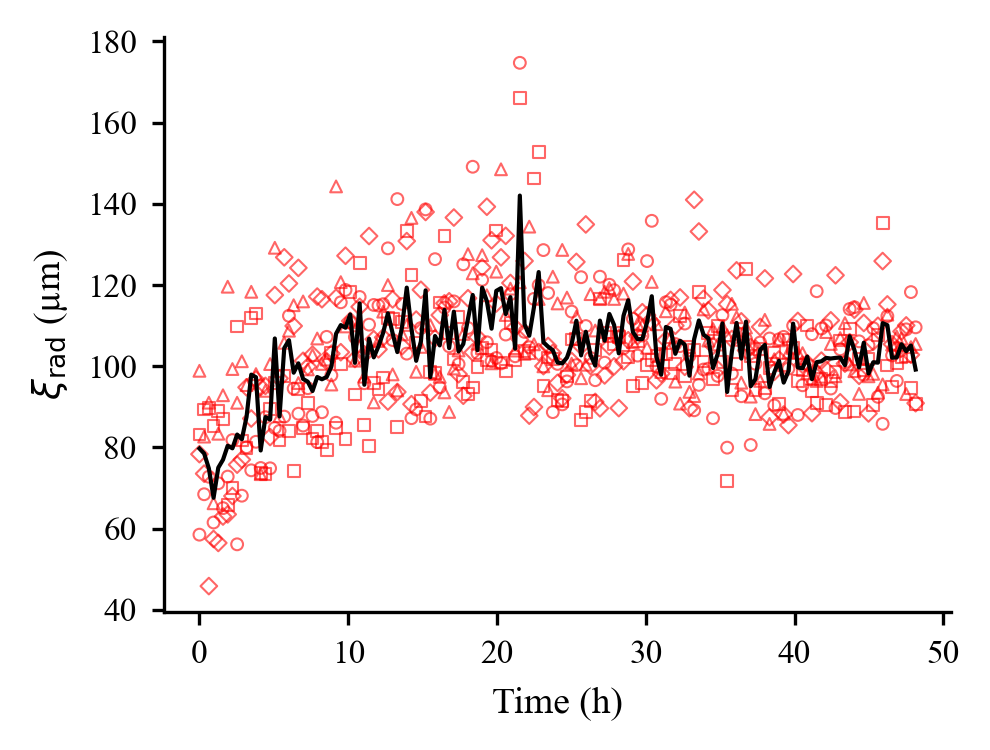

[DONE] Saved figure to: C:\Users\oxfil\mask_corr_length_radial\corr_length_timeseries_xi_e_um_by_cell.png


In [125]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

CSV_PATH = r"mask_corr_length_radial\corr_radial_length_per_cell_frame.csv"

METRIC_COL = "xi_e_um"   # metric_choose

# frame index -> time
DT_MIN     = 19.0        # 1 frame = 19 min
TIME_UNIT  = "hour"      # "min" or "hour"

OUT_PNG    = r"C:\Users\oxfil\mask_corr_length_radial\corr_length_timeseries_xi_e_um_by_cell.png"

FIGSIZE    = (3.4, 2.6)  
DPI        = 300

SCATTER_ALPHA = 0.6
SCATTER_SIZE  = 8

MEAN_LINE_WIDTH = 1.0    

TITLE  = r"Radial correlation length vs time"
YLABEL = r"$\xi_{\mathrm{rad}}$ (µm)"

matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

df = pd.read_csv(CSV_PATH)

for col in ["t", "cell_id", METRIC_COL]:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found. columns = {df.columns.tolist()}")

df_plot = df[["t", "cell_id", METRIC_COL]].copy()
df_plot = df_plot.dropna(subset=[METRIC_COL])

# ---------- frame -> time ----------
if TIME_UNIT == "min":
    df_plot["time"] = df_plot["t"] * DT_MIN
    x_label = "Time (min)"
elif TIME_UNIT == "hour":
    df_plot["time"] = df_plot["t"] * DT_MIN / 60.0
    x_label = "Time (h)"
else:
    df_plot["time"] = df_plot["t"]
    x_label = "Frame index"

cell_ids = sorted(df_plot["cell_id"].unique())
print("[INFO] cell_ids:", cell_ids)


cmap = plt.get_cmap("tab10")
colors = {cid: cmap(i % 10) for i, cid in enumerate(cell_ids)}

markers = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "<", ">"]
marker_map = {cid: markers[i % len(markers)] for i, cid in enumerate(cell_ids)}

#   Figure 
fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

# (a) Scatter plots for each cell_id
for cid in cell_ids:
    df_c = df_plot[df_plot["cell_id"] == cid]
    ax.scatter(
        df_c["time"],
        df_c[METRIC_COL],
        s=SCATTER_SIZE,
        alpha=SCATTER_ALPHA,
        edgecolors="red",
        linewidth = 0.5,
        color="none",
        marker=marker_map[cid],
        label=f"Cell {cid}"
    )

# (b) Mean line for all samples
group_all = df_plot.groupby("time")[METRIC_COL]
time_grid = group_all.mean().index.values
mean_vals = group_all.mean().values

ax.plot(
    time_grid,
    mean_vals,
    "-",
    lw=MEAN_LINE_WIDTH,
    color="black",
    label="Mean (all cells)"
)

ax.set_xlabel(x_label)
ax.set_ylabel(YLABEL)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(direction="out", length=3)
# ax.legend(frameon=False, fontsize=7, loc="best")

fig.tight_layout()

os.makedirs(os.path.dirname(OUT_PNG), exist_ok=True)
fig.savefig(OUT_PNG, bbox_inches="tight")
plt.show()

print(f"[DONE] Saved figure to: {OUT_PNG}")
